# Challenge 02 — Inteligencia Geo-Temporal y de Redes
### Optimización de Activos Críticos: TechLogistics S.A.

**Maestría en Ciencia de los Datos y Analítica — EAFIT — Periodo 2026-1**

**Briefing de consultoría:** TechLogistics S.A. enfrenta un problema de visibilidad: los datos de la cadena de frío (agroindustria) y de la red eléctrica están georreferenciados pero desconectados. Este notebook responde, para la junta directiva: (1) cómo se propaga el ruido en la red de sensores (Grafos), (2) dónde se localizan los puntos críticos de calor (Geoespacial), y (3) cuál es el pronóstico de carga (Series de Tiempo).

**Metodología:** CRISP-DM / Análisis Multicapa.

In [1]:
# Imports generales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from scipy import signal
from scipy.fft import fft, fftfreq

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.statespace.sarimax import SARIMAX

import networkx as nx

DATA_DIR = "../data"

## Fase 1: Data Understanding y Geo-Visualización

### 1.1 Carga y EDA de `agro_clean.csv`

Cargamos el dataset agroindustrial (sensores mesh en el oriente antioqueño) y revisamos tipos, nulos y estadísticos descriptivos antes de cualquier análisis espacial o temporal.

In [2]:
agro_clean = pd.read_csv(f"{DATA_DIR}/agro_clean.csv")
agro_noise = pd.read_csv(f"{DATA_DIR}/agro_noise.csv")

agro_clean.head()

,Agro_1,Agro_2,Agro_3,Agro_4,Agro_5,Agro_6,Agro_7,Agro_8,Agro_9,Agro_10,Latitude,Longitude,Source_Node,Target_Node
0,60.248357,47.797447,65.395554,0.000000,0.478718,2.498349,10.000000,6.432151,1.258741,4.663639,6.203680,-75.400366,4,17
1,60.080940,48.076702,66.143237,25.002075,0.467100,2.473166,10.006672,6.469450,1.106051,4.683748,6.282310,-75.474525,14,21
2,60.623974,48.002378,66.342755,49.941596,0.449259,2.464547,10.013349,6.440262,1.183610,8.353141,6.165190,-75.476937,14,22
3,61.211672,48.267738,66.826015,74.756163,0.439299,2.500284,10.020030,6.511042,1.197917,6.213966,6.131334,-75.468152,8,25
4,60.483063,47.912028,65.703353,99.383693,0.436016,2.564177,10.026716,6.619718,1.200795,8.720976,6.241746,-75.349805,5,26


### 1.2 Tarea 1 — Exploración Geo-Temporal

Visualizamos la ubicación de los sensores con `scatter_mapbox` (Plotly Express): color codificado por NDVI (`Agro_5`) y tamaño por Humedad (`Agro_1`).

**Pregunta a responder:** ¿Existe algún patrón espacial (clustering) donde la biomasa sea consistentemente baja?

In [3]:
fig = px.scatter_mapbox(
    agro_clean,
    lat="Latitude",
    lon="Longitude",
    color="Agro_5",
    size="Agro_1",
    color_continuous_scale="RdYlGn",
    size_max=12,
    zoom=9,
    mapbox_style="open-street-map",
    hover_data=["Source_Node", "Target_Node", "Agro_5", "Agro_1"],
    title="Sensores agroindustriales (oriente antioqueño): NDVI (color) vs Humedad (tamaño)",
)
fig.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0})
fig.show()

C:\Users\danie\AppData\Local\Temp\ipykernel_33800\3716443753.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [4]:
# Diagnóstico de clustering espacial: promedio de NDVI por celda de una grilla espacial
n_bins = 6
agro_clean["lat_bin"] = pd.cut(agro_clean["Latitude"], bins=n_bins)
agro_clean["lon_bin"] = pd.cut(agro_clean["Longitude"], bins=n_bins)

grid = (
    agro_clean.groupby(["lat_bin", "lon_bin"], observed=True)
    .agg(ndvi_mean=("Agro_5", "mean"), n=("Agro_5", "size"))
    .reset_index()
)
grid = grid[grid["n"] >= 15].sort_values("ndvi_mean")

print(f"NDVI promedio global: {agro_clean['Agro_5'].mean():.3f}")
print(f"Desv. estándar entre medias de celdas espaciales: {grid['ndvi_mean'].std():.3f}")
print(f"Desv. estándar de NDVI a nivel de registro (ruido temporal): {agro_clean['Agro_5'].std():.3f}")
print()
print("Celdas espaciales con NDVI promedio más bajo (n >= 15 registros):")
print(grid.head(5).to_string(index=False))
print()
print("Celdas espaciales con NDVI promedio más alto (n >= 15 registros):")
print(grid.tail(5).to_string(index=False))

agro_clean = agro_clean.drop(columns=["lat_bin", "lon_bin"])

NDVI promedio global: 1.158
Desv. estándar entre medias de celdas espaciales: 0.047
Desv. estándar de NDVI a nivel de registro (ruido temporal): 0.379

Celdas espaciales con NDVI promedio más bajo (n >= 15 registros):
       lat_bin            lon_bin  ndvi_mean  n
(6.133, 6.167]   (-75.5, -75.467]   1.067324 50
(6.133, 6.167] (-75.367, -75.334]   1.074305 55
(6.233, 6.267] (-75.367, -75.334]   1.078103 59
  (6.1, 6.133]   (-75.5, -75.467]   1.080785 43
  (6.2, 6.233]   (-75.334, -75.3]   1.100490 69

Celdas espaciales con NDVI promedio más alto (n >= 15 registros):
       lat_bin            lon_bin  ndvi_mean  n
(6.233, 6.267]   (-75.5, -75.467]   1.205429 55
  (6.167, 6.2] (-75.467, -75.433]   1.219445 57
  (6.267, 6.3]   (-75.433, -75.4]   1.220652 66
  (6.1, 6.133]   (-75.4, -75.367]   1.241259 66
  (6.267, 6.3]   (-75.5, -75.467]   1.243158 44


**Análisis (clustering espacial de biomasa baja):** el mapa no muestra una zona
geográfica donde la biomasa (NDVI, `Agro_5`) sea *consistentemente* baja. El NDVI promedio
por celda espacial (grilla 6x6 sobre el oriente antioqueño) varía muy poco entre celdas
(desviación estándar entre medias ≈ 0.047) frente a la dispersión de NDVI a nivel de
registro (≈ 0.38): la diferencia entre la celda más "verde" y la más "seca" es de apenas
~0.18 unidades de NDVI alrededor de una media global de 1.16, un rango comparable al ruido
natural de la medición. En otras palabras, la variabilidad del NDVI está dominada por la
dinámica temporal de cada sensor (la serie es no estacionaria I(1), ver diccionario de
datos) y no por su ubicación: no hay evidencia de un foco geográfico de biomasa baja que
amerite, por sí solo, una intervención localizada — la Tarea P2 profundiza en esto
cruzando NDVI con la varianza del viento como proxy de pendiente.

### 1.3 Tarea 2 — Análisis de Estacionariedad y Windowing

Aplicamos el test **ADF** a las series de energía (`ener_clean.csv`). Para las series no estacionarias, calculamos media y varianza móvil con ventana de 50 registros, y evaluamos si el Costo del Gas (`Ener_5`) es una serie con *Drift* o *Random Walk*.

In [5]:
ener_clean = pd.read_csv(f"{DATA_DIR}/ener_clean.csv")
ener_noise = pd.read_csv(f"{DATA_DIR}/ener_noise.csv")

ener_cols = [f"Ener_{i}" for i in range(1, 11)]
adf_results = []
for col in ener_cols:
    stat, pvalue, *_ = adfuller(ener_clean[col], autolag="AIC")
    adf_results.append({"serie": col, "adf_stat": stat, "p_value": pvalue, "no_estacionaria": pvalue > 0.05})

adf_df = pd.DataFrame(adf_results)
non_stationary_cols = adf_df.loc[adf_df["no_estacionaria"], "serie"].tolist()

print(adf_df.to_string(index=False))
print()
print("Series NO estacionarias (p-value > 0.05):", non_stationary_cols)

  serie      adf_stat  p_value  no_estacionaria
 Ener_1 -1.866891e+00 0.347793             True
 Ener_2 -1.479135e+00 0.543807             True
 Ener_3 -1.928441e+00 0.318802             True
 Ener_4 -1.336821e+10 0.000000            False
 Ener_5 -3.477077e-01 0.918470             True
 Ener_6  9.526991e-01 0.993741             True
 Ener_7 -4.244451e-01 0.905937             True
 Ener_8 -4.603634e+01 0.000000            False
 Ener_9 -4.535819e+01 0.000000            False
Ener_10 -4.371511e+01 0.000000            False

Series NO estacionarias (p-value > 0.05): ['Ener_1', 'Ener_2', 'Ener_3', 'Ener_5', 'Ener_6', 'Ener_7']


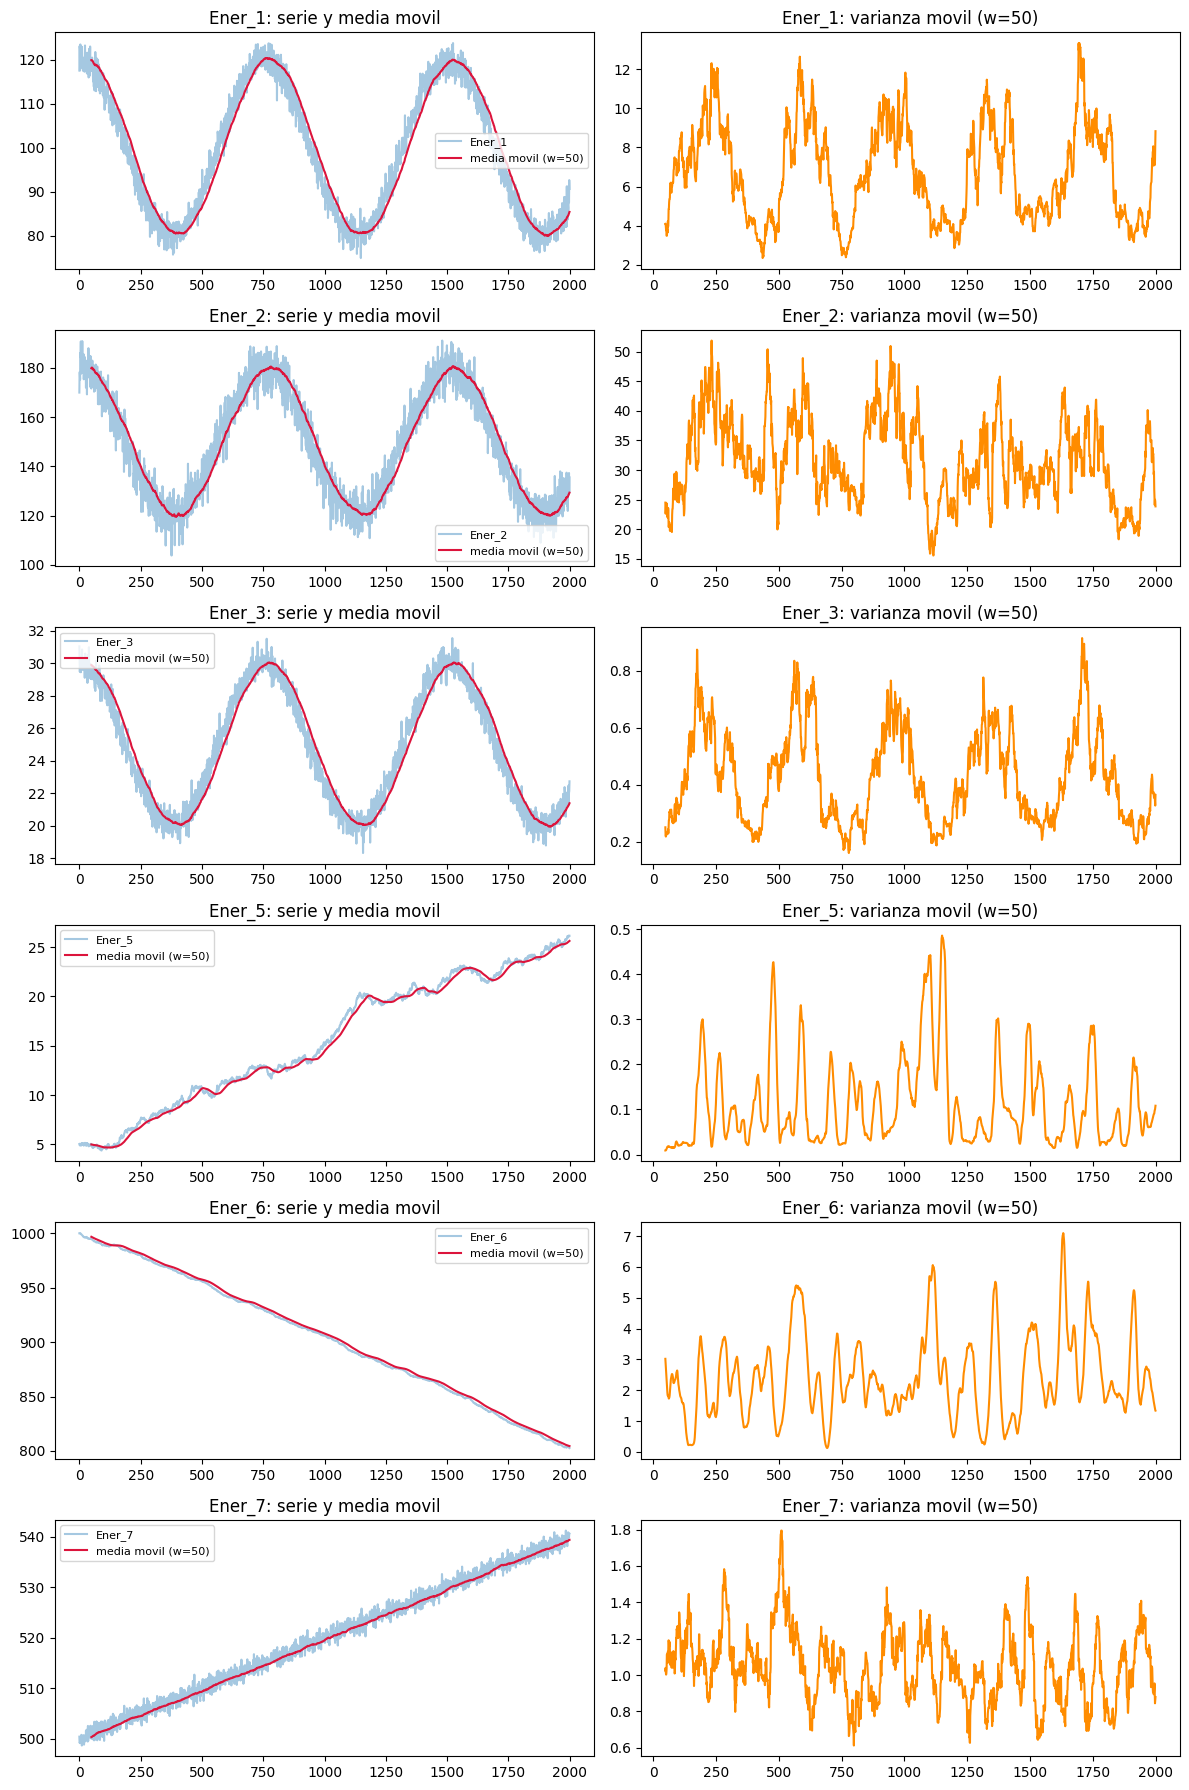

In [6]:
# Media y varianza movil (ventana = 50) para las series no estacionarias
window = 50
fig, axes = plt.subplots(len(non_stationary_cols), 2, figsize=(12, 3 * len(non_stationary_cols)))

for i, col in enumerate(non_stationary_cols):
    roll_mean = ener_clean[col].rolling(window=window).mean()
    roll_var = ener_clean[col].rolling(window=window).var()

    axes[i, 0].plot(ener_clean[col], alpha=0.4, label=col)
    axes[i, 0].plot(roll_mean, color="crimson", label=f"media movil (w={window})")
    axes[i, 0].set_title(f"{col}: serie y media movil")
    axes[i, 0].legend(fontsize=8)

    axes[i, 1].plot(roll_var, color="darkorange")
    axes[i, 1].set_title(f"{col}: varianza movil (w={window})")

plt.tight_layout()
plt.show()

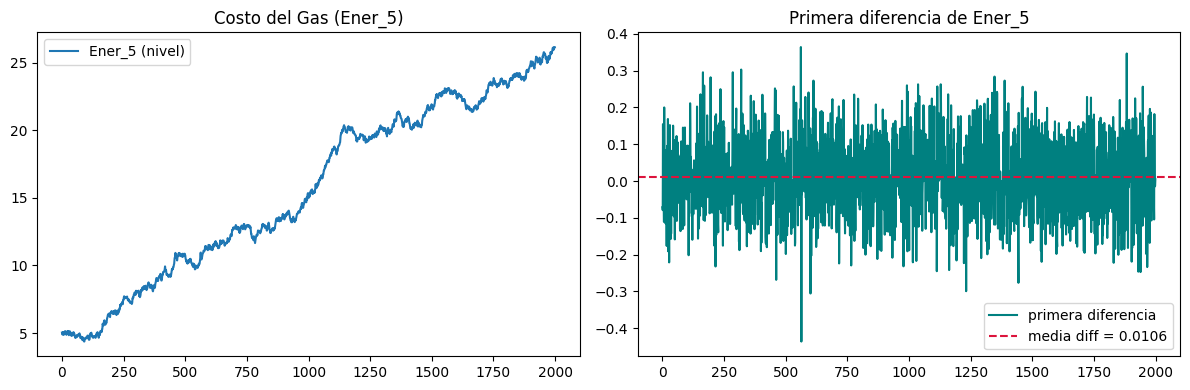

Media de la primera diferencia: 0.0106
Desv. estandar de la primera diferencia: 0.1012
Cambio total observado (nivel final - nivel inicial): 21.11


In [7]:
# Costo del Gas (Ener_5): ?Drift o Random Walk?
ener5_diff = ener_clean["Ener_5"].diff().dropna()
diff_mean, diff_std = ener5_diff.mean(), ener5_diff.std()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ener_clean["Ener_5"], label="Ener_5 (nivel)")
axes[0].set_title("Costo del Gas (Ener_5)")
axes[0].legend()

axes[1].plot(ener5_diff, color="teal", label="primera diferencia")
axes[1].axhline(diff_mean, color="crimson", linestyle="--", label=f"media diff = {diff_mean:.4f}")
axes[1].set_title("Primera diferencia de Ener_5")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Media de la primera diferencia: {diff_mean:.4f}")
print(f"Desv. estandar de la primera diferencia: {diff_std:.4f}")
print(f"Cambio total observado (nivel final - nivel inicial): {ener_clean['Ener_5'].iloc[-1] - ener_clean['Ener_5'].iloc[0]:.2f}")

**Análisis (Drift vs Random Walk de `Ener_5`):** el test ADF no rechaza la hipótesis
nula de raíz unitaria para `Ener_5` (p-value ≈ 0.92, estadístico ≈ -0.35), confirmando que
es no estacionaria (I(1), tal como indica el diccionario de datos). Su primera diferencia
sí es estacionaria (ADF p-value ≈ 0.0). La serie sube de forma casi monótona de ~5 a ~26 a
lo largo de las 2000 observaciones; su primera diferencia tiene media distinta de cero
(≈ +0.0106) pero con una desviación estándar (~0.10) casi 10 veces mayor que esa media —
es decir, el impulso determinístico por paso es pequeño frente al ruido por paso, pero al
acumularse en 2000 pasos termina dominando la trayectoria. Esto es la firma clásica de un
**Random Walk con Drift** (no un random walk puro sin tendencia, ni una serie puramente
determinística sin ruido): $Ener\_5_t = Ener\_5_{t-1} + \mu + \varepsilon_t$ con
$\mu \approx 0.0106 > 0$. Para modelar o pronosticar esta serie es necesario diferenciarla
(I(1) → I(0)) antes de ajustar un ARMA, e incluir el término de drift explícitamente.

De las 10 variables de energía, el ADF marca como no estacionarias `Ener_1, Ener_2, Ener_3,
Ener_5, Ener_6, Ener_7` (mercado spot y factores macro) — todas requieren diferenciación
antes de análisis de correlación o modelado ARIMA (ver pregunta de autoevaluación #1). Las
variables de calidad de potencia (`Ener_8, Ener_9, Ener_10`) resultan estacionarias, y
`Ener_4` (generación eólica) es fuertemente estacionaria en el sentido del ADF pese a su
comportamiento cíclico/intermitente, coherente con el diccionario de datos.

## Fase 2: Procesamiento de Señales y Filtrado

### 2.1 Tarea 3 — Análisis Espectral (FFT) y Espectrogramas

Analizamos `Ener_4` (Generación Eólica): extraemos la densidad espectral de potencia mediante FFT y comparamos el espectrograma de la serie *clean* vs *noise*.

**Pregunta a responder:** ¿En qué rango de frecuencias se concentra el ruido inyectado (SNR ∈ [5, 12] dB)?

In [8]:
# TODO: f_clean, t_clean, Sxx_clean = signal.spectrogram(ener_clean["Ener_4"])
#       f_noise, t_noise, Sxx_noise = signal.spectrogram(ener_noise["Ener_4"])
#       comparar Sxx_clean vs Sxx_noise en subplots

**Análisis (banda de frecuencia del ruido):** _completar tras comparar espectrogramas._

### 2.2 Tarea 4 — Filtrado y Reconstrucción

Implementamos un **Filtro Butterworth** de paso bajo para limpiar `Agro_3` (Humedad Relativa) en `agro_noise.csv`, y calculamos el RMSE contra la serie `agro_clean.csv`.

**Pregunta a responder:** ¿El filtrado mejora la capacidad predictiva del modelo?

In [9]:
# TODO: b, a = signal.butter(N=4, Wn=..., btype="low")
#       agro3_filtered = signal.filtfilt(b, a, agro_noise["Agro_3"])
#       rmse = np.sqrt(np.mean((agro3_filtered - agro_clean["Agro_3"]) ** 2))

**Análisis (RMSE y mejora predictiva):** _completar tras aplicar el filtro._

## Fase 3: Análisis de Grafos y Topología de Red

### 3.1 Tarea 5 — Construcción de la Red de Subestaciones

Usando `Source_Node` y `Target_Node` de `ener_clean.csv`, creamos un grafo dirigido con **NetworkX**, calculamos Centralidad de Grado y Betweenness Centrality, e identificamos el **Nodo Cuello de Botella** (por donde pasa la mayor cantidad de telemetría). La centralidad del nodo de origen se guardará para usarse como variable exógena en el ARIMAX de la Tarea P3.

In [10]:
# TODO: G = nx.from_pandas_edgelist(ener_clean, source="Source_Node", target="Target_Node",
#                                   create_using=nx.DiGraph())
#       degree_centrality = nx.degree_centrality(G)
#       betweenness_centrality = nx.betweenness_centrality(G)
#       bottleneck_node = max(betweenness_centrality, key=betweenness_centrality.get)

**Análisis (nodo cuello de botella):** _completar tras calcular las centralidades._

## Fase 4: Modelado y Toma de Decisiones (CRISP-DM)

**Problema de negocio — La Falla del Nodo 214:** cuando el Precio Spot (`Ener_2`) supera el umbral crítico, el flujo hacia ciertos `Target_Node` se interrumpe, y los datos geoespaciales muestran una anomalía térmica en esas coordenadas.

### 4.1 P1 — Causalidad y Redes

Ejecutamos un test de **Causalidad de Granger** entre el Factor de Potencia (`Ener_10`) y el Voltaje (`Ener_9`).

In [11]:
# TODO: grangercausalitytests(ener_clean[["Ener_9", "Ener_10"]], maxlag=5)

**Respuesta P1:** _si existe causalidad, ¿cómo afectaría un fallo en el nodo con mayor Betweenness Centrality (Tarea 5) a la estabilidad del resto de la red?_

### 4.2 P2 — Optimización Geo-Agrónoma

Filtramos el ruido de las coordenadas GPS en `agro_noise.csv` y cruzamos los sensores con menor NDVI (`Agro_5`) contra la varianza del viento (`Agro_10`, proxy de pendiente).

In [12]:
# TODO: suavizado espacial de Latitude/Longitude en agro_noise (p.ej. rolling mean por Source_Node)
#       cruce entre Agro_5 (NDVI) bajo y Agro_10 (varianza del viento) como proxy de pendiente

**Respuesta P2 (recomendación de inversión en infraestructura hídrica):** _completar tras el análisis._

### 4.3 P3 — Analítica Predictiva (ARIMAX)

Ajustamos un modelo **ARIMAX** para la Demanda (`Ener_1`), usando como variables exógenas la Temperatura (`Ener_3`) y la Centralidad del Nodo de origen (Tarea 5). Comparamos el AIC con y sin la centralidad.

In [13]:
# TODO: modelo_sin_centralidad = SARIMAX(ener_clean["Ener_1"], exog=ener_clean[["Ener_3"]], order=(...)).fit()
#       modelo_con_centralidad = SARIMAX(ener_clean["Ener_1"], exog=ener_clean[["Ener_3", "centralidad_nodo"]], order=(...)).fit()
#       comparar modelo_sin_centralidad.aic vs modelo_con_centralidad.aic

**Respuesta P3 (¿mejora el AIC al incluir la centralidad del nodo?):** _completar tras ajustar ambos modelos._

## 5. Conclusiones Ejecutivas y Recomendaciones

_Síntesis para la junta directiva de TechLogistics S.A.: hallazgos clave de geoespacial, señales, grafos y modelado, y recomendaciones accionables._

## 6. Preguntas de Autoevaluación (Checklist de Entrega)

1. **Estacionariedad:** ¿Por qué no es válido aplicar un análisis de correlación de Pearson directamente sobre una serie con tendencia (como el NDVI o el Precio de Exportación)? — _completar._
2. **SNR:** ¿Qué impacto tuvo el ruido de 5dB en la estimación de los coeficientes del modelo ARMA comparado con la versión Clean? — _completar._
3. **Topología:** ¿Cómo cambia la interpretación de un fallo en un sensor si este es un "Bridge" (puente) en el grafo de la red? — _completar._
4. **Geo-Inteligencia:** ¿Cómo influye la posición geográfica en la varianza de la señal capturada? — _completar._